In [1]:
import geokit as gk
from tqdm import tqdm
from modelBuilder.data import default_path_information


In [2]:
shapeFilePath = default_path_information["general_data"]["default_regions_shp"]
regions_df = gk.vector.extractFeatures(shapeFilePath)

In [3]:
redefine_basefile = False #if True, island/nationally isolated status and area column will be redefined

In [4]:
# define an aux function that returns area in sq. kms for a geom in lat/lon
def get_area(geom):
    srs = gk.srs.centeredLAEA(geom.Centroid().GetX(), geom.Centroid().GetY())
    return gk.geom.transform(geom, toSRS=srs).Area()/1000000 # return area in km²

if redefine_basefile: 
    islands = []
    national_isolated = []
    for reg_geom, country in tqdm(zip(regions_df.geom, regions_df.GID_0), total=len(regions_df)):
        sub_df = gk.vector.extractFeatures(shapeFilePath, geom=reg_geom)
        # append a boolean if the region is an island
        islands.append(len(sub_df)==1)
        # check if other regions from the same country are bordering, if not append to national isolated regions list
        national_isolated.append( len(sub_df[sub_df.GID_0==country])==1 )

    regions_df['island']=islands
    regions_df['nat_isol']=national_isolated

    # CALCULATE AREAS

    # add an area column with values ins sq kms
    areas=[]
    for g in tqdm(regions_df.geom):
        areas.append(get_area(g))
    regions_df['area_km2']=areas

    # save the resulting vector with area column and island/nationally isolated status
    gk.vector.createVector(
        regions_df,
       default_path_information["general_data"]["default_regions_shp"],
    )

else:
    regions_df = gk.vector.extractFeatures(
        default_path_information["general_data"]["default_regions_shp"]
        )
    print("Regions shapefile with island/national isolation status and areas in sq. kms loaded from disk.")

print(round(regions_df.island.sum()/len(regions_df)*100,2), "% of regions are islands.")
print(round(regions_df.nat_isol.sum()/len(regions_df)*100,2), "% of regions are nationally isolated.")

Regions shapefile with island/national isolation status and areas in sq. kms loaded from disk.
6.35 % of regions are islands.
7.0 % of regions are nationally isolated.


In [15]:
regions_df[regions_df.GID_0=='PRI']

,geom,GID_0,NAME_0,GID_1,NAME_1,region_id,Union_No,island,area_km2,nat_isol
2544,"POLYGON ((-66.797737121582 18.1336479187012,-6...",PRI,Puerto Rico,PRI.1_1,Adjuntas,PRI.1_1,3.0,0,175.024050,0
2545,"POLYGON ((-67.1301193237305 18.3180484771729,-...",PRI,Puerto Rico,PRI.2_1,Aguada,PRI.2_1,3.0,0,80.318897,0
2546,"POLYGON ((-67.0562286376953 18.4609241485597,-...",PRI,Puerto Rico,PRI.3_1,Aguadilla,PRI.3_1,3.0,0,95.102685,0
2547,"POLYGON ((-66.1688079833983 18.2242336273193,-...",PRI,Puerto Rico,PRI.4_1,Aguas Buenas,PRI.4_1,3.0,0,79.844740,0
2548,"POLYGON ((-66.2244491577148 18.095329284668,-6...",PRI,Puerto Rico,PRI.5_1,Aibonito,PRI.5_1,3.0,0,80.570187,0
...,...,...,...,...,...,...,...,...,...,...
2617,"POLYGON ((-66.3773040771484 18.3442249298097,-...",PRI,Puerto Rico,PRI.74_1,Vega Baja,PRI.74_1,3.0,0,120.996940,0
2618,MULTIPOLYGON (((-65.4334716796875 18.091527938...,PRI,Puerto Rico,PRI.75_1,Vieques,PRI.75_1,3.0,1,136.947919,1
2619,"POLYGON ((-66.522087097168 18.1518478393555,-6...",PRI,Puerto Rico,PRI.76_1,Villalba,PRI.76_1,3.0,0,95.425752,0
2620,"POLYGON ((-66.0102310180664 18.0755653381348,-...",PRI,Puerto Rico,PRI.77_1,Yabucoa,PRI.77_1,3.0,0,144.515763,0


In [5]:
# # check out some regions that are nationally isolated but NOT islands
# regions_df[(regions_df.nat_isol==True)&(regions_df.island==False)]

In [16]:
max_regions = 150
verbose=False
union_No = 3 #default: None

all_national_shapes_df = gk.vector.extractFeatures(
    default_path_information["general_data"]["default_regions_shp"],
)

if union_No is None: 
    unions = sorted(list(regions_df.Union_No.unique()))
else:
    assert isinstance(union_No, int), f"union_No must be an int if not None"
    unions =[union_No]

for union in unions:

    print("Now processing Union No.", union)

    union_df = regions_df[regions_df.Union_No==union]
    current_regions_per_union = len(union_df)
    if verbose: print(current_regions_per_union, "regions found in union No.", union)

    country_areas = union_df.groupby('GID_0')['area_km2'].sum()
    initial_regions_per_country = union_df.groupby('GID_0')['GID_0'].count()
    current_nonisland_regions_per_country =  (union_df.groupby('GID_0')['GID_0'].count() - union_df.groupby('GID_0')['nat_isol'].sum())

    # if initial_regions_per_country = union_df.groupby('GID_0')['GID_0'].count().sum()

    # assert current_nonisland_regions_per_country.sum() - len(current_nonisland_regions_per_country) >= max_regions, f"Union No. {union} has less connected regions than required ({current_nonisland_regions_per_country.sum() + +union_df.groupby('GID_0')['nat_isol'].sum().sum()} instead of {max_regions})"

    while current_nonisland_regions_per_country.sum() + union_df.groupby('GID_0')['nat_isol'].sum().sum() > max_regions:
        assert len(current_nonisland_regions_per_country[current_nonisland_regions_per_country>1])>0, f"No more nation left with more than 2 non-island regions." #TODO this COULD continue even if the remaining 2 mainland regions are on different mainlands!
        # identify the biggest problem i.e. country with the smallest average region size
        schlimmer_finger = (country_areas/current_nonisland_regions_per_country).sort_values()[(country_areas/current_nonisland_regions_per_country).sort_values().index.isin(list(current_nonisland_regions_per_country[current_nonisland_regions_per_country>1].index))].index[0]
        # reduce the region amount for the schlimmer_finger
        current_nonisland_regions_per_country[schlimmer_finger] = current_nonisland_regions_per_country[schlimmer_finger]-1 
        if verbose: print(schlimmer_finger, "reduced")  

    # now set the new number of regions in the respective regions_df dataset columns
    # regions_df.set_index("GID_0", inplace=True)
    for country in country_areas.index:
        all_national_shapes_df.loc[list(all_national_shapes_df[all_national_shapes_df.GID_0==country].index.values), 'regNo_red']=(current_nonisland_regions_per_country+union_df.groupby('GID_0')['nat_isol'].sum())[country]
        all_national_shapes_df.loc[list(all_national_shapes_df[all_national_shapes_df.GID_0==country].index.values), 'regNo_init']=initial_regions_per_country[country]
    # regions_df.reset_index(drop=True, inplace=True)


Now processing Union No. 3


In [ ]:
all_national_shapes_df["reduction"]=1-(all_national_shapes_df['regNo_red']/all_national_shapes_df['regNo_init'])
ax=gk.drawGeoms(all_national_shapes_df[~all_national_shapes_df['reduction'].isna()], colorBy='reduction', cbarTitle=f"Reduction factor for max. {max_regions} regions per Union (globally {int(all_national_shapes_df['regNo_red'].sum())} regions)\n(final / initial region amount) [-]", figsize=(30,12), linewidth=0.05, hideAxis=True)

In [ ]:
import pandas as pd
results_df=pd.DataFrame()
results_df['max_per_union']=[731,   500,  300,  250,  200,  180,  150,  100]
results_df['regions_sum']=  [3827, 3596, 3334, 3184, 2924, 2778, 2552, 2001]
import matplotlib.pyplot as plt
plt.scatter(x=results_df['max_per_union'], y=results_df['regions_sum'])
plt.xlabel("max. No. of regions per Union")
plt.ylabel("Total number of global regions")

In [ ]:
# calculate the area for each national shape in sq km
all_national_shapes_df['area_km2']=all_national_shapes_df.apply(lambda x : get_area(x.geom), axis=1)

In [ ]:
all_national_shapes_df['km2_p_reg']=all_national_shapes_df['area_km2']/all_national_shapes_df['regNo_init']
ax=gk.drawGeoms(
    all_national_shapes_df[~all_national_shapes_df['km2_p_reg'].isna()], 
    colorBy='km2_p_reg', 
    cbarTitle=f"Average region size per country [km²/region]\n (global average {int(all_national_shapes_df['km2_p_reg'].mean())} km²/region, total {len(regions_df)} regions)", 
    vmax=all_national_shapes_df[~all_national_shapes_df['km2_p_reg'].isna()]['km2_p_reg'].quantile(0.99),
    figsize=(30,12), 
    linewidth=0.05, 
    hideAxis=True)

Plot data for union No. 3


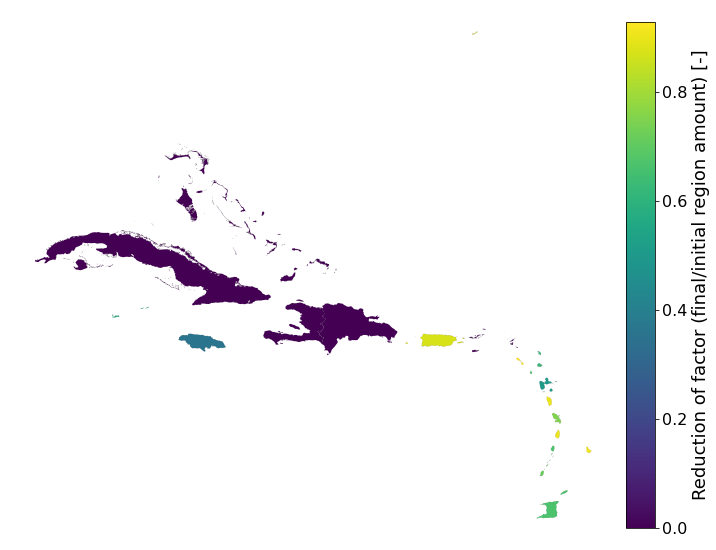

In [17]:
# PLOT A SINGLE UNION

print("Plot data for union No.", union)

final_regions_per_country = current_nonisland_regions_per_country+union_df.groupby('GID_0')['nat_isol'].sum()
country_list="','".join(list(final_regions_per_country.index))
union_national_shapes_df = gk.vector.extractFeatures(
    default_path_information["general_data"]["default_regions_shp"],
    where=f"GID_0 in ('{country_list}')"
)
union_national_shapes_df.sort_values('GID_0', inplace=True)
union_national_shapes_df['reduction']=1-(final_regions_per_country/initial_regions_per_country).values

ax=gk.drawGeoms(union_national_shapes_df, colorBy='reduction', cbarTitle="Reduction of factor (final/initial region amount) [-]", figsize=(10,8), linewidth=0.05, hideAxis=True)